In [1]:
import os
from concurrent .futures .thread import ThreadPoolExecutor

import pandas as pd

os .environ ['US_TIGER_SHAPEFILE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/TIGER/tl_2020_us_county/tl_2020_us_county.shp'
os .environ ['CANADA_CENSUS_DIVISIONS_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/CanadaBoundaries/lcd_000b21a_e/lcd_000b21a_e.shp'
os .environ ['DATA_CACHE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/'


In [2]:
from research_spring_2025 import get_selected_regions
from research_spring_2025 import generate_h3_grid_from_gdf

counties =get_selected_regions ()
cells =generate_h3_grid_from_gdf (counties ,use_cached_file =True )


In [3]:
import rasterio
from rasterstats import zonal_stats

from tqdm .contrib .concurrent import thread_map

import matplotlib .pyplot as plt


In [8]:
base_directory ='/Users/aaronspaulding/data/TCC/'

input_files ={

'2018':base_directory +'science_tcc_CONUS_2018_v2023-5_wgs84/science_tcc_conus_wgs84_v2023-5_20180101_20181231.tif',
'2019':base_directory +'science_tcc_CONUS_2019_v2023-5_wgs84/science_tcc_conus_wgs84_v2023-5_20190101_20191231.tif',
'2020':base_directory +'science_tcc_CONUS_2020_v2023-5_wgs84/science_tcc_conus_wgs84_v2023-5_20200101_20201231.tif',
'2021':base_directory +'science_tcc_CONUS_2021_v2023-5_wgs84/science_tcc_conus_wgs84_v2023-5_20210101_20211231.tif',
'2022':base_directory +'science_tcc_CONUS_2022_v2023-5_wgs84/science_tcc_conus_wgs84_v2023-5_20220101_20221231.tif',
'2023':base_directory +'science_tcc_CONUS_2023_v2023-5_wgs84/science_tcc_conus_wgs84_v2023-5_20230101_20231231.tif',
}


In [10]:
for year ,path in input_files .items ():
    print ('Processing {}...'.format (year ))

    raster_path_for_this_year =path

    print ('\tOpening Data')
    with rasterio .open (path )as src :
        raster_array =src .read (1 )
        affine =src .transform
        nodata_val =src .nodata
        crs =src .crs

    cells_projected =cells .to_crs (src .crs ).copy ()

    print ('\tProcessing Data for Cells')
    geom_tuples =list (enumerate (cells_projected .geometry ))

    def process_geometry (idx_geom ):
        idx ,geom =idx_geom
        try :
            stats =zonal_stats (
            geom ,
            raster_array ,
            affine =affine ,
            stats =['mean'],
            nodata =nodata_val
            )
            return idx ,stats [0 ]['mean']
        except Exception :
            return idx ,None

    results =thread_map (process_geometry ,geom_tuples ,max_workers =8 ,chunksize =50 ,desc ='Processing cells')
    mean_values =[None ]*len (cells_projected )
    for idx ,mean in results :
        mean_values [idx ]=mean

    cells [f'tree_canopy_cover_{year}']=mean_values


Processing 2018...
	Opening Data
	Processing Data for Cells


Processing cells:   0%|          | 0/3571572 [00:00<?, ?it/s]

Processing 2019...
	Opening Data
	Processing Data for Cells


Processing cells:   0%|          | 0/3571572 [00:00<?, ?it/s]

Processing 2020...
	Opening Data
	Processing Data for Cells


...

Processing cells:   0%|          | 0/3571572 [00:00<?, ?it/s]

Processing 2022...
	Opening Data
	Processing Data for Cells


Processing cells:   0%|          | 0/3571572 [00:00<?, ?it/s]

Processing 2023...
	Opening Data
	Processing Data for Cells


Processing cells:   0%|          | 0/3571572 [00:00<?, ?it/s]

In [12]:
cells .drop (columns ='geometry').reset_index (drop =True ).to_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_TCC.feather')


In [32]:
tcc_data =pd .read_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_TCC.feather')
cells =generate_h3_grid_from_gdf (counties ,use_cached_file =True )

cells =cells .merge (tcc_data ,on ='index',how ='left')
cells .shape


(3571572, 12)

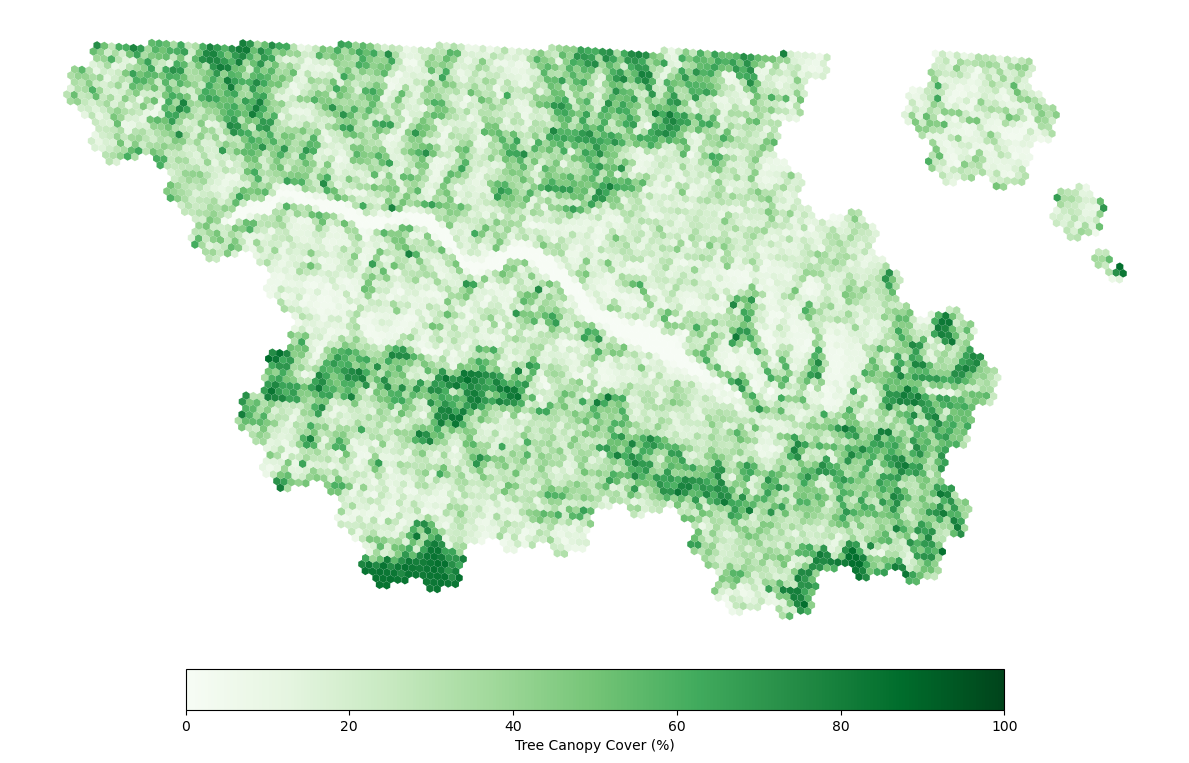

In [33]:
fig ,ax =plt .subplots (figsize =(12 ,10 ))
fig .patch .set_facecolor ('white')

cells .plot (
ax =ax ,
column ='tree_canopy_cover_2023',
cmap =plt .cm .Greens ,
linewidth =0 ,
edgecolor ='none',
legend =True ,
vmin =0. ,
vmax =100. ,
legend_kwds ={
'label':'Tree Canopy Cover (%)',
'shrink':0.7 ,
'orientation':'horizontal',
'pad':0.02
}
)

ax .axis ('off')

plt .tight_layout ()
plt .show ()


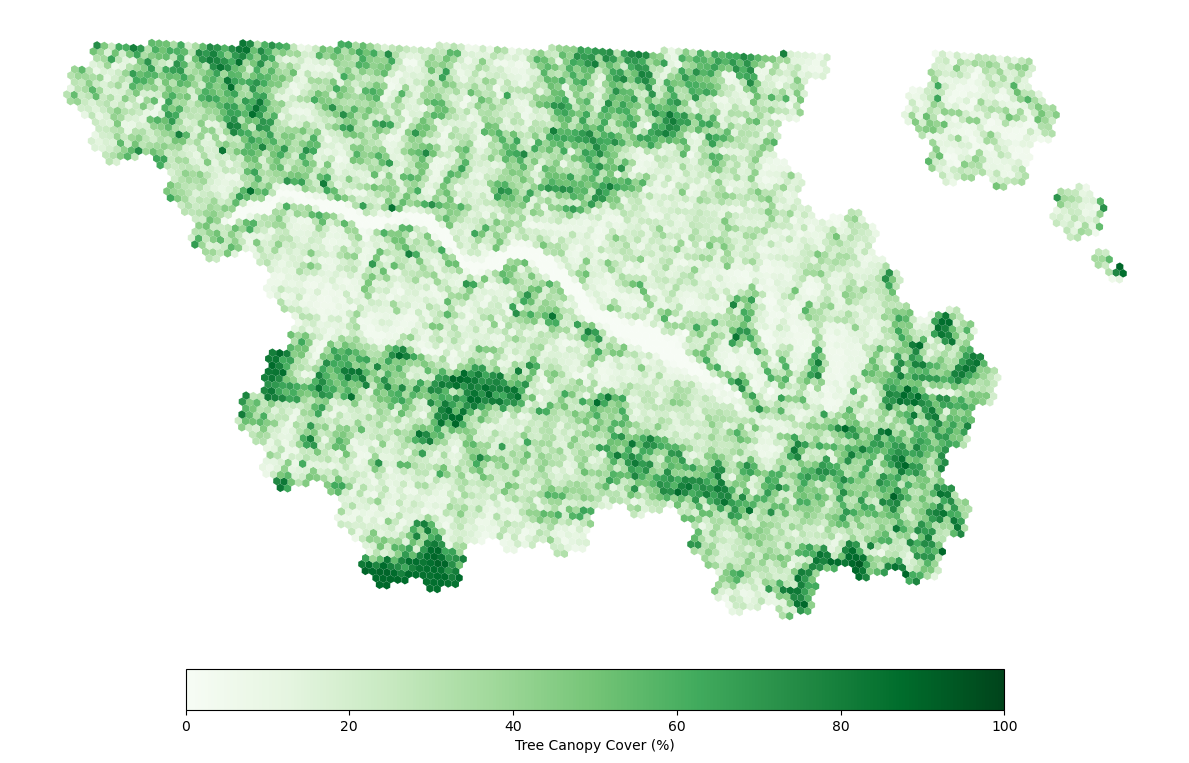

In [34]:
fig ,ax =plt .subplots (figsize =(12 ,10 ))
fig .patch .set_facecolor ('white')

cells .plot (
ax =ax ,
column ='tree_canopy_cover_2014',
cmap =plt .cm .Greens ,
linewidth =0 ,
edgecolor ='none',
legend =True ,
vmin =0. ,
vmax =100. ,
legend_kwds ={
'label':'Tree Canopy Cover (%)',
'shrink':0.7 ,
'orientation':'horizontal',
'pad':0.02
}
)

ax .axis ('off')

plt .tight_layout ()
plt .show ()
